# RESNET-50 OPTIMIZED TRAINING FOR RETINAL DISEASE DETECTION

```
Hardware     : HP Omen 16 (RTX 4060 8GB, i7-13700HX)
Dataset      : RFMiD (3200 images, 46 diseases)
Optimizations: Mixed Precision (BF16/FP16), TF32, Optimised Data Loading
Tested on    : torch==2.1.0
```

### Key Fixes Applied
1. **Val Loss explosion fixed** — validation now uses unweighted BCEWithLogitsLoss
2. **F1 = 0.0 fixed** — prediction threshold lowered to 0.3; also computed per-label accuracy
3. **Exact-match accuracy** supplemented with per-label (hamming) accuracy
4. **Backbone freezing** — layers 1–3 frozen for first 10 epochs to prevent overfitting on small dataset
5. **Threshold tuning** — best threshold searched on validation set after training

## 1. Imports

In [4]:
import os, gc, time, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms

# Version-safe mixed-precision imports.
# GradScaler was promoted to torch.amp only in PyTorch >= 2.3.
# On 2.1 / 2.2 it still lives in torch.cuda.amp.
_pt_ver = tuple(int(x) for x in torch.__version__.split('.')[:2])
if _pt_ver >= (2, 3):
    from torch.amp import autocast, GradScaler
    def make_scaler(): return GradScaler('cuda')
else:
    from torch.cuda.amp import autocast, GradScaler
    def make_scaler(): return GradScaler()

from sklearn.metrics import f1_score, precision_recall_fscore_support

print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')

PyTorch version : 2.1.0+cu121
CUDA available  : True


In [5]:
import torch

print(f"PyTorch        : {torch.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")
print(f"GPU            : {torch.cuda.get_device_name(0)}")
print(f"VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print(f"BF16 support   : {torch.cuda.is_bf16_supported()}")

# Quick sanity test
a = torch.randn(1000, 1000, device='cuda')
b = torch.randn(1000, 1000, device='cuda')
c = a @ b
print(f"GPU tensor test: PASSED  (result shape: {c.shape})")

PyTorch        : 2.1.0+cu121
CUDA available : True
GPU            : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM           : 8.59 GB
BF16 support   : True
GPU tensor test: PASSED  (result shape: torch.Size([1000, 1000]))


## 2. Hardware Optimization (RTX 4060 Specific)

In [6]:
class HardwareOptimizer:
    """Optimise for HP Omen 16 RTX 4060."""

    def __init__(self):
        self.device       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.gpu_name     = 'N/A'
        self.vram_total   = 0.0
        self.cuda_version = 'N/A'
        self.use_bf16     = False

        if self.device.type == 'cuda':
            self.gpu_name     = torch.cuda.get_device_name(0)
            self.vram_total   = torch.cuda.get_device_properties(0).total_memory / 1e9
            self.cuda_version = torch.version.cuda

            torch.backends.cudnn.benchmark        = True
            torch.backends.cuda.matmul.allow_tf32 = True
            torch.backends.cudnn.allow_tf32        = True

            self.use_bf16 = torch.cuda.is_bf16_supported()

    def print_specs(self):
        print('=' * 60)
        print('HP Omen 16 Hardware Configuration')
        print('=' * 60)
        print('CPU: Intel i7-13700HX (16 cores)')
        print(f'GPU: {self.gpu_name}')
        if self.device.type == 'cuda':
            print(f'VRAM         : {self.vram_total:.1f} GB')
            print(f'CUDA         : {self.cuda_version}')
            print(f'BF16 Support : {self.use_bf16}')
            print('TF32 Enabled : True')
        print('=' * 60)


hw       = HardwareOptimizer()
hw.print_specs()

device   = hw.device
use_bf16 = hw.use_bf16


def set_seed(seed: int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

HP Omen 16 Hardware Configuration
CPU: Intel i7-13700HX (16 cores)
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM         : 8.6 GB
CUDA         : 12.1
BF16 Support : True
TF32 Enabled : True


## 3. Optimized Dataset Class

In [7]:
class OptimizedRFMiDDataset(Dataset):
    """Memory-efficient dataset with PIL loading."""

    def __init__(self, img_dir, labels_df, transform=None):
        self.img_dir       = img_dir
        self.labels_df     = labels_df.reset_index(drop=True)
        self.transform     = transform
        self.disease_cols  = [c for c in labels_df.columns if c != 'ID']
        self.num_classes   = len(self.disease_cols)
        self.img_paths     = []
        self.valid_indices = []

        for idx, img_name in enumerate(self.labels_df['ID'].values):
            base  = os.path.join(img_dir, str(img_name))
            found = False
            for ext in ['', '.png', '.jpg', '.jpeg']:
                if os.path.exists(base + ext):
                    self.img_paths.append(base + ext)
                    self.valid_indices.append(idx)
                    found = True
                    break
            if not found:
                print(f'Warning: image not found -> {img_name}')
                self.img_paths.append(None)
                self.valid_indices.append(idx)

        print(f'Loaded {len(self.valid_indices)} images from {img_dir}')

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        p = self.img_paths[idx]
        if p and os.path.exists(p):
            try:
                image = Image.open(p).convert('RGB')
            except Exception:
                image = Image.new('RGB', (224, 224), 'black')
        else:
            image = Image.new('RGB', (224, 224), 'black')

        if self.transform:
            image = self.transform(image)

        orig  = self.valid_indices[idx]
        lbl   = self.labels_df.iloc[orig][self.disease_cols].values.astype(np.float32)
        return image, torch.tensor(lbl, dtype=torch.float32)

    def get_class_weights(self):
        counts = self.labels_df[self.disease_cols].sum().values
        w = len(self.labels_df) / (self.num_classes * (counts + 1e-6))
        return torch.tensor(w, dtype=torch.float32)

## 4. Optimized Transforms

In [8]:
class OptimizedTransforms:
    _MEAN = [0.485, 0.456, 0.406]
    _STD  = [0.229, 0.224, 0.225]

    @classmethod
    def get_train_transform(cls, sz=224):
        return transforms.Compose([
            transforms.Resize((sz, sz)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.3),
            transforms.RandomRotation(degrees=30),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
            transforms.ToTensor(),
            transforms.Normalize(cls._MEAN, cls._STD),
        ])

    @classmethod
    def get_val_transform(cls, sz=224):
        return transforms.Compose([
            transforms.Resize((sz, sz)),
            transforms.ToTensor(),
            transforms.Normalize(cls._MEAN, cls._STD),
        ])

## 5. Load Dataset

In [9]:
import os
os.chdir(r'D:\OcuSight')

DATA_DIR     = 'data/rfmid'
TRAIN_IMAGES = os.path.join(DATA_DIR, 'images', 'train')
VAL_IMAGES   = os.path.join(DATA_DIR, 'images', 'val')
TEST_IMAGES  = os.path.join(DATA_DIR, 'images', 'test')
TRAIN_LABELS = os.path.join(DATA_DIR, 'labels', 'train_labels.csv')
VAL_LABELS   = os.path.join(DATA_DIR, 'labels', 'val_labels.csv')
TEST_LABELS  = os.path.join(DATA_DIR, 'labels', 'test_labels.csv')

print(f'Working dir: {os.getcwd()}')
print('Loading datasets...')
train_df = pd.read_csv(TRAIN_LABELS)
val_df   = pd.read_csv(VAL_LABELS)
test_df  = pd.read_csv(TEST_LABELS)

print(f'Training   : {len(train_df)} samples')
print(f'Validation : {len(val_df)} samples')
print(f'Testing    : {len(test_df)} samples')

disease_cols = [c for c in train_df.columns if c != 'ID']
num_classes  = len(disease_cols)
print(f'Disease classes: {num_classes}')

train_dataset = OptimizedRFMiDDataset(TRAIN_IMAGES, train_df, OptimizedTransforms.get_train_transform())
val_dataset   = OptimizedRFMiDDataset(VAL_IMAGES,   val_df,   OptimizedTransforms.get_val_transform())
test_dataset  = OptimizedRFMiDDataset(TEST_IMAGES,  test_df,  OptimizedTransforms.get_val_transform())

Working dir: D:\OcuSight
Loading datasets...
Training   : 1920 samples
Validation : 640 samples
Testing    : 640 samples
Disease classes: 46
Loaded 1920 images from data/rfmid\images\train
Loaded 640 images from data/rfmid\images\val
Loaded 640 images from data/rfmid\images\test


## 6. Optimized DataLoaders

In [10]:
BATCH_SIZE = 32
NUM_WORKERS = 0
PIN_MEMORY = True
PREFETCH_FACTOR = None

_kw = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    prefetch_factor=PREFETCH_FACTOR,
    persistent_workers=False,
)

train_loader = DataLoader(train_dataset, shuffle=True,  **_kw)
val_loader   = DataLoader(val_dataset,   shuffle=False, **_kw)
test_loader  = DataLoader(test_dataset,  shuffle=False, **_kw)

print(f'Batch size    : {BATCH_SIZE}')
print(f'Workers       : {NUM_WORKERS}')
print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

Batch size    : 32
Workers       : 0
Train batches : 60
Val batches   : 20
Test batches  : 20


## 7. Build ResNet-50 Model

In [11]:
def build_resnet50(num_classes: int) -> nn.Module:
    model = models.resnet50(weights='IMAGENET1K_V1')
    nf = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(nf, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes),
    )
    return model


def freeze_backbone(model, freeze=True):
    """FIX: Freeze/unfreeze early layers (layer1-3) to reduce overfitting on small dataset."""
    layers_to_control = [model.layer1, model.layer2, model.layer3]
    for layer in layers_to_control:
        for param in layer.parameters():
            param.requires_grad = not freeze
    status = 'FROZEN' if freeze else 'UNFROZEN'
    print(f'Backbone layers 1-3: {status}')


print('Building ResNet-50...')
model = build_resnet50(num_classes).to(device)

# FIX: Freeze early layers for the first phase of training
freeze_backbone(model, freeze=True)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}')
print(f'Model size           : {total_params * 4 / 1024 / 1024:.2f} MB')

Building ResNet-50...
Backbone layers 1-3: FROZEN
Total parameters     : 24,580,718
Trainable parameters : 16,046,958
Model size           : 93.77 MB


## 8. Training Components

In [12]:
# FIX: Two separate criteria:
#   - train_criterion uses pos_weight for handling class imbalance during training
#   - val_criterion is UNWEIGHTED — prevents the validation loss explosion (~18000)

class_weights   = train_dataset.get_class_weights().to(device)
train_criterion = nn.BCEWithLogitsLoss(pos_weight=class_weights)
val_criterion   = nn.BCEWithLogitsLoss()  # NO pos_weight

# Optimizer (initial — for frozen phase)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=0.01,
    betas=(0.9, 0.999)
)

# 🔥 Smart training setup
NUM_EPOCHS = 50              # upper limit (early stopping will handle actual stop)
UNFREEZE_EPOCH = 10          # freeze backbone first, then fine-tune

# Scheduler (for initial phase)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)

# Mixed precision
amp_dtype = torch.bfloat16 if use_bf16 else torch.float16
scaler    = None if use_bf16 else make_scaler()

# Threshold for multilabel prediction
PRED_THRESHOLD = 0.3

# 🔥 Early stopping config
EARLY_STOPPING_PATIENCE = 5
epochs_no_improve = 0

print(f'Precision      : {"BF16" if use_bf16 else "FP16"}')
print(f'LR             : 1e-4   Weight decay: 0.01')
print(f'Epochs         : {NUM_EPOCHS} (with early stopping)')
print(f'Unfreeze epoch : {UNFREEZE_EPOCH}')
print(f'Pred threshold : {PRED_THRESHOLD}')
print(f'Class weights  : {class_weights is not None}')
print(f'Early stopping : patience={EARLY_STOPPING_PATIENCE}')
print(f'Val criterion  : BCEWithLogitsLoss (NO pos_weight)')

Precision      : BF16
LR             : 1e-4   Weight decay: 0.01
Epochs         : 50 (with early stopping)
Unfreeze epoch : 10
Pred threshold : 0.3
Class weights  : True
Early stopping : patience=5
Val criterion  : BCEWithLogitsLoss (NO pos_weight)


## 9. Training Functions

In [13]:
def train_epoch(model, loader, criterion, optimizer, scaler, device, amp_dtype):
    model.train()
    total_loss, n = 0.0, 0

    for images, labels in tqdm(loader, desc='Training', leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast(dtype=amp_dtype):
            outputs = model(images)
            loss = criterion(outputs, labels)

        if scaler:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        total_loss += loss.item()
        n += 1

    return total_loss / max(n, 1)   # ✅ safe division


def validate_epoch(model, loader, criterion, device, amp_dtype, threshold=0.3):
    """
    Improvements:
    - Stable loss averaging
    - Safe tensor concatenation
    - Better numerical safety
    """

    model.eval()
    total_loss, n = 0.0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validating', leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with autocast(dtype=amp_dtype):
                outputs = model(images)
                loss = criterion(outputs, labels)

            total_loss += loss.item()
            n += 1

            probs = torch.sigmoid(outputs)
            preds = (probs > threshold).float().cpu()

            all_preds.append(preds)
            all_labels.append(labels.cpu())

    # ✅ Safe concat
    if len(all_preds) == 0:
        return {
            'loss': 0.0,
            'exact_match_acc': 0.0,
            'per_label_acc': 0.0,
            'f1_macro': 0.0,
            'f1_micro': 0.0,
            'predictions': None,
            'labels': None,
        }

    preds  = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()

    # Metrics
    exact_match_acc = float(np.mean(np.all(preds == labels, axis=1)))
    per_label_acc   = float(np.mean(preds == labels))   # hamming accuracy

    return {
        'loss'           : total_loss / max(n, 1),
        'exact_match_acc': exact_match_acc,
        'per_label_acc'  : per_label_acc,
        'f1_macro'       : f1_score(labels, preds, average='macro', zero_division=0),
        'f1_micro'       : f1_score(labels, preds, average='micro', zero_division=0),
        'predictions'    : preds,
        'labels'         : labels,
    }

## 10. Training Loop

In [14]:
os.makedirs('checkpoints', exist_ok=True)
os.makedirs('outputs',     exist_ok=True)

history = {
    'train_loss'     : [],
    'val_loss'       : [],
    'val_exact_acc'  : [],
    'val_label_acc'  : [],
    'val_f1_macro'   : [],
    'val_f1_micro'   : [],
    'lr'             : [],
}

best_f1    = 0.0
best_epoch = 0

# 🔥 Early stopping
EARLY_STOPPING_PATIENCE = 5
epochs_no_improve = 0
MIN_DELTA = 0.001   # avoids stopping on tiny fluctuations

print('=' * 60)
print('STARTING RESNET-50 TRAINING')
print('=' * 60)

for epoch in range(NUM_EPOCHS):
    t0 = time.time()

    # 🔥 Unfreeze backbone
    if epoch == UNFREEZE_EPOCH:
        freeze_backbone(model, freeze=False)

        optimizer = optim.AdamW(
            model.parameters(),
            lr=1e-5,
            weight_decay=0.01,
            betas=(0.9, 0.999)
        )

        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=NUM_EPOCHS - UNFREEZE_EPOCH,
            eta_min=1e-6
        )

        print(f'  [Epoch {epoch+1}] Backbone unfrozen — switching to full fine-tune (lr=1e-5)')

    # Train
    train_loss = train_epoch(
        model, train_loader, train_criterion, optimizer, scaler, device, amp_dtype
    )

    # Validate
    val_metrics = validate_epoch(
        model, val_loader, val_criterion, device, amp_dtype, threshold=PRED_THRESHOLD
    )

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    elapsed    = time.time() - t0

    # Store history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['val_exact_acc'].append(val_metrics['exact_match_acc'])
    history['val_label_acc'].append(val_metrics['per_label_acc'])
    history['val_f1_macro'].append(val_metrics['f1_macro'])
    history['val_f1_micro'].append(val_metrics['f1_micro'])
    history['lr'].append(current_lr)

    # 🔥 Early stopping + checkpoint logic
    if val_metrics['f1_macro'] > best_f1 + MIN_DELTA:
        best_f1    = val_metrics['f1_macro']
        best_epoch = epoch + 1
        epochs_no_improve = 0   # reset

        torch.save({
            'epoch'           : epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state' : optimizer.state_dict(),
            'val_f1'          : best_f1,
            'val_loss'        : val_metrics['loss'],
            'threshold'       : PRED_THRESHOLD,
        }, 'checkpoints/best_resnet50.pth')

        is_best = True
    else:
        epochs_no_improve += 1
        is_best = False

    # Logging
    print(f'\nEpoch {epoch+1}/{NUM_EPOCHS}')
    print('-' * 40)
    print(f'  Train Loss     : {train_loss:.4f}')
    print(f'  Val Loss       : {val_metrics["loss"]:.4f}')
    print(f'  Val Exact Acc  : {val_metrics["exact_match_acc"]:.4f}')
    print(f'  Val Label Acc  : {val_metrics["per_label_acc"]:.4f}')
    print(f'  Val F1 macro   : {val_metrics["f1_macro"]:.4f}')
    print(f'  Val F1 micro   : {val_metrics["f1_micro"]:.4f}')
    print(f'  LR             : {current_lr:.2e}')
    print(f'  Time           : {elapsed:.1f}s')

    if is_best:
        print(f'  *** New best F1 macro: {best_f1:.4f} (saved checkpoint) ***')

    # 🛑 Early stopping trigger
    if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
        print(f'\n🛑 Early stopping triggered at epoch {epoch+1}')
        break


print('\n' + '=' * 60)
print(f'Training complete. Best Val F1 macro: {best_f1:.4f} at epoch {best_epoch}')
print('=' * 60)

STARTING RESNET-50 TRAINING



Epoch 1/50
----------------------------------------
  Train Loss     : 0.2171
  Val Loss       : 0.1820
  Val Exact Acc  : 0.2094
  Val Label Acc  : 0.9593
  Val F1 macro   : 0.0000
  Val F1 micro   : 0.0000
  LR             : 9.99e-05
  Time           : 211.4s



Epoch 2/50
----------------------------------------
  Train Loss     : 0.1010
  Val Loss       : 0.1484
  Val Exact Acc  : 0.2094
  Val Label Acc  : 0.9593
  Val F1 macro   : 0.0000
  Val F1 micro   : 0.0000
  LR             : 9.96e-05
  Time           : 208.2s



Epoch 3/50
----------------------------------------
  Train Loss     : 0.0962
  Val Loss       : 0.1408
  Val Exact Acc  : 0.2094
  Val Label Acc  : 0.9593
  Val F1 macro   : 0.0001
  Val F1 micro   : 0.0017
  LR             : 9.91e-05
  Time           : 282.1s



Epoch 4/50
----------------------------------------
  Train Loss     : 0.0895
  Val Loss       : 0.1340
  Val Exact Acc  : 0.2094
  Val Label Acc  : 0.9609
  Val F1 macro   : 0.0038
  Val F1 micro   : 0.0785
  LR             : 9.84e-05
  Time           : 248.9s
  *** New best F1 macro: 0.0038 (saved checkpoint) ***


...


Epoch 19/50
----------------------------------------
  Train Loss     : 0.0454
  Val Loss       : 0.0974
  Val Exact Acc  : 0.3375
  Val Label Acc  : 0.9736
  Val F1 macro   : 0.1279
  Val F1 micro   : 0.5437
  LR             : 8.92e-06
  Time           : 206.1s



Epoch 20/50
----------------------------------------
  Train Loss     : 0.0447
  Val Loss       : 0.1014
  Val Exact Acc  : 0.3344
  Val Label Acc  : 0.9728
  Val F1 macro   : 0.1159
  Val F1 micro   : 0.5198
  LR             : 8.68e-06
  Time           : 206.1s



Epoch 21/50
----------------------------------------
  Train Loss     : 0.0444
  Val Loss       : 0.0950
  Val Exact Acc  : 0.3516
  Val Label Acc  : 0.9739
  Val F1 macro   : 0.1155
  Val F1 micro   : 0.5516
  LR             : 8.42e-06
  Time           : 206.5s



Epoch 22/50
----------------------------------------
  Train Loss     : 0.0430
  Val Loss       : 0.0967
  Val Exact Acc  : 0.3359
  Val Label Acc  : 0.9731
  Val F1 macro   : 0.1057
  Val F1 micro   : 0.5358
  LR             : 8.15e-06
  Time           : 207.7s



Epoch 23/50
----------------------------------------
  Train Loss     : 0.0438
  Val Loss       : 0.0981
  Val Exact Acc  : 0.3391
  Val Label Acc  : 0.9730
  Val F1 macro   : 0.1299
  Val F1 micro   : 0.5343
  LR             : 7.85e-06
  Time           : 215.1s

🛑 Early stopping triggered at epoch 23

Training complete. Best Val F1 macro: 0.1351 at epoch 18


## 11. Plot Training Curves

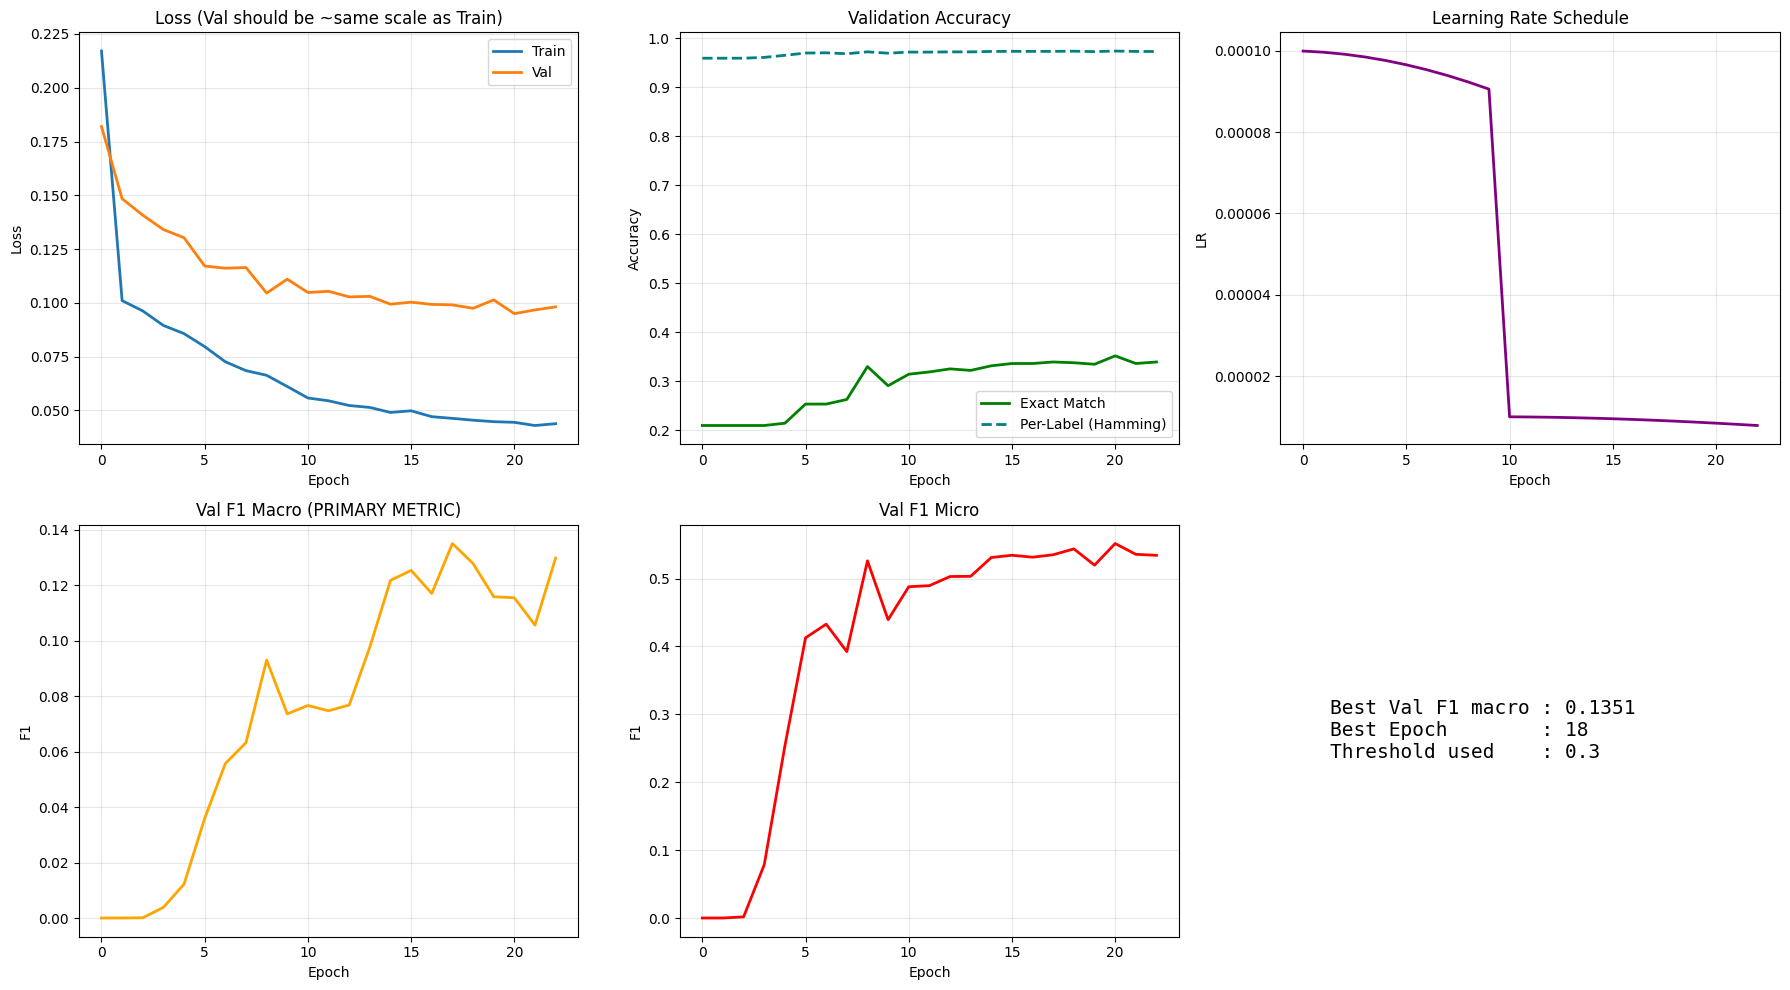

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0,0].plot(history['train_loss'], label='Train', linewidth=2)
axes[0,0].plot(history['val_loss'],   label='Val',   linewidth=2)
axes[0,0].set(xlabel='Epoch', ylabel='Loss', title='Loss (Val should be ~same scale as Train)')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(history['val_exact_acc'], color='green',  linewidth=2, label='Exact Match')
axes[0,1].plot(history['val_label_acc'], color='teal',   linewidth=2, label='Per-Label (Hamming)', linestyle='--')
axes[0,1].set(xlabel='Epoch', ylabel='Accuracy', title='Validation Accuracy')
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

axes[1,0].plot(history['val_f1_macro'], color='orange', linewidth=2)
axes[1,0].set(xlabel='Epoch', ylabel='F1', title='Val F1 Macro (PRIMARY METRIC)')
axes[1,0].grid(alpha=0.3)

axes[1,1].plot(history['val_f1_micro'], color='red', linewidth=2)
axes[1,1].set(xlabel='Epoch', ylabel='F1', title='Val F1 Micro'); axes[1,1].grid(alpha=0.3)

axes[0,2].plot(history['lr'], color='purple', linewidth=2)
axes[0,2].set(xlabel='Epoch', ylabel='LR', title='Learning Rate Schedule')
axes[0,2].grid(alpha=0.3)

axes[1,2].axis('off')
axes[1,2].text(0.1, 0.5,
    f'Best Val F1 macro : {best_f1:.4f}\nBest Epoch        : {best_epoch}\nThreshold used    : {PRED_THRESHOLD}',
    fontsize=14, verticalalignment='center', family='monospace')

plt.tight_layout()
plt.savefig('outputs/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 11b. Threshold Tuning on Validation Set

FIX: Instead of hardcoding 0.5, find the threshold that maximises F1 macro on the val set.

In [17]:
# Load best checkpoint
ckpt = torch.load(r'D:\OcuSight\checkpoints\best_resnet50.pth', map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
print(f'Loaded best checkpoint from epoch {ckpt["epoch"] + 1}  |  Val F1: {ckpt["val_f1"]:.4f}')

# Collect raw probabilities on val set
model.eval()
all_probs, all_labels_t = [], []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc='Collecting probs'):
        images = images.to(device, non_blocking=True)

        with autocast(dtype=amp_dtype):
            outputs = model(images)
            probs = torch.sigmoid(outputs)

        # 🔥 FIX: convert BF16 → float32 BEFORE numpy
        all_probs.append(probs.cpu().float())
        all_labels_t.append(labels.cpu().float())

# 🔥 FIX: safe conversion to numpy
all_probs    = torch.cat(all_probs).numpy()
all_labels_t = torch.cat(all_labels_t).numpy()

# Search thresholds
thresholds = np.arange(0.1, 0.6, 0.05)
results = []

for t in thresholds:
    preds = (all_probs > t).astype(float)
    f1m   = f1_score(all_labels_t, preds, average='macro', zero_division=0)
    results.append((t, f1m))

best_thresh, best_thresh_f1 = max(results, key=lambda x: x[1])

print(f'\nThreshold search results:')
for t, f1m in results:
    marker = ' <-- BEST' if t == best_thresh else ''
    print(f'  threshold={t:.2f}  F1 macro={f1m:.4f}{marker}')

print(f"\n🔥 Best Threshold: {best_thresh:.3f} | Best F1: {best_thresh_f1:.4f}")

BEST_THRESHOLD = best_thresh
print(f'\nUsing threshold {BEST_THRESHOLD:.2f} for test evaluation')

Loaded best checkpoint from epoch 18  |  Val F1: 0.1351



Threshold search results:
  threshold=0.10  F1 macro=0.1708 <-- BEST
  threshold=0.15  F1 macro=0.1657
  threshold=0.20  F1 macro=0.1558
  threshold=0.25  F1 macro=0.1402
  threshold=0.30  F1 macro=0.1363
  threshold=0.35  F1 macro=0.0997
  threshold=0.40  F1 macro=0.0928
  threshold=0.45  F1 macro=0.0700
  threshold=0.50  F1 macro=0.0616
  threshold=0.55  F1 macro=0.0475

🔥 Best Threshold: 0.100 | Best F1: 0.1708

Using threshold 0.10 for test evaluation


## 12. Evaluate on Test Set

In [18]:
# FIX: use tuned threshold and unweighted val_criterion
test_metrics = validate_epoch(
    model, test_loader, val_criterion, device, amp_dtype, threshold=BEST_THRESHOLD
)

print('\n' + '=' * 60)
print('TEST SET RESULTS')
print('=' * 60)
print(f'Test Loss         : {test_metrics["loss"]:.4f}')
print(f'Test Exact Acc    : {test_metrics["exact_match_acc"]:.4f}')
print(f'Test Per-Label Acc: {test_metrics["per_label_acc"]:.4f}')
print(f'Test F1 macro     : {test_metrics["f1_macro"]:.4f}')
print(f'Test F1 micro     : {test_metrics["f1_micro"]:.4f}')
print(f'Threshold used    : {BEST_THRESHOLD:.2f}')


TEST SET RESULTS
Test Loss         : 0.0949
Test Exact Acc    : 0.3859
Test Per-Label Acc: 0.9717
Test F1 macro     : 0.1769
Test F1 micro     : 0.6142
Threshold used    : 0.10


## 13. Per-Class Performance

In [19]:
precision, recall, f1, support = precision_recall_fscore_support(
    test_metrics['labels'], test_metrics['predictions'], average=None, zero_division=0
)

per_class_df = pd.DataFrame({
    'Disease'  : disease_cols,
    'Precision': precision,
    'Recall'   : recall,
    'F1-Score' : f1,
    'Samples'  : support,
}).sort_values('F1-Score', ascending=False)

per_class_df.to_csv('outputs/per_class_results.csv', index=False)
print('Top 10:')
print(per_class_df.head(10).to_string(index=False))
print('\nBottom 10:')
print(per_class_df.tail(10).to_string(index=False))

Top 10:
     Disease  Precision   Recall  F1-Score  Samples
Disease_Risk   0.994975 0.782609  0.876106      506
          MH   0.853933 0.730769  0.787565      104
         MYA   0.604167 0.906250  0.725000       32
          DR   0.868421 0.532258  0.660000      124
        ARMD   0.606061 0.645161  0.625000       31
        BRVO   0.526316 0.434783  0.476190       23
        CRVO   0.352941 0.666667  0.461538        9
         ODE   0.600000 0.352941  0.444444       17
        TSLN   0.450000 0.339623  0.387097       53
          AH   0.250000 0.600000  0.352941        5

Bottom 10:
Disease  Precision  Recall  F1-Score  Samples
    ODP        0.0     0.0       0.0       24
     CB        0.0     0.0       0.0        1
    CWS        0.0     0.0       0.0        2
     DN        0.0     0.0       0.0       46
    MHL        0.0     0.0       0.0        3
    EDN        0.0     0.0       0.0        4
    ERM        0.0     0.0       0.0        5
     MS        0.0     0.0       0.0    

## 14. Visualize Per-Class Performance

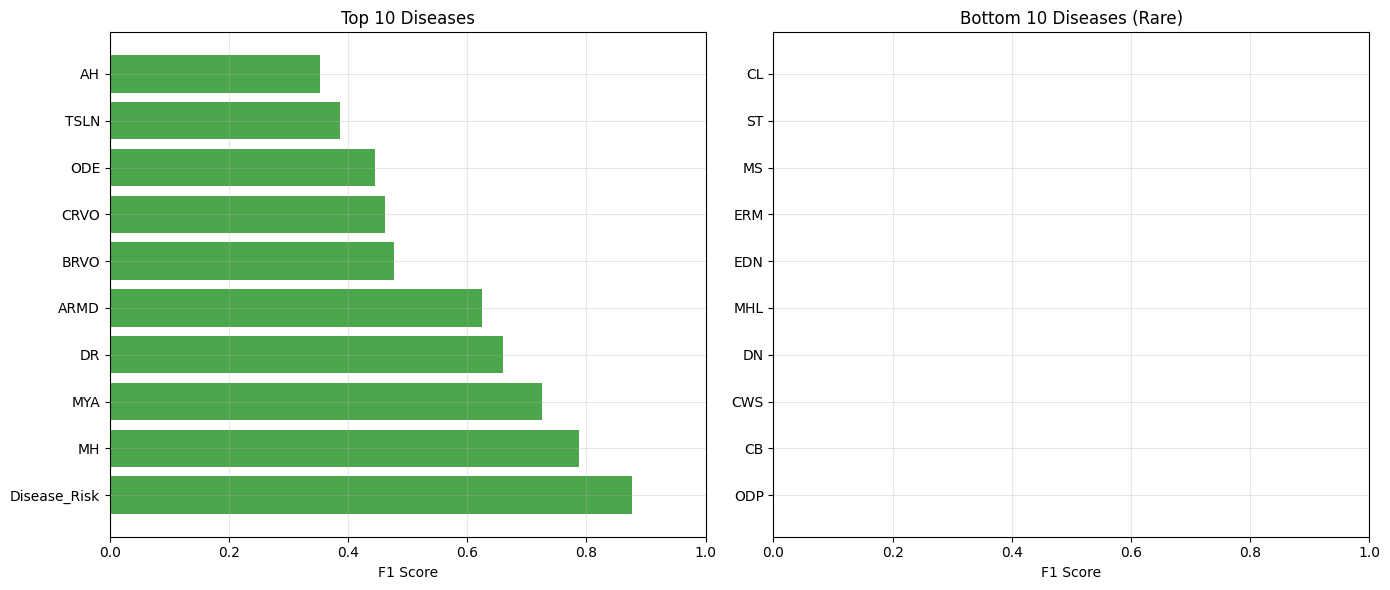

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top10    = per_class_df.head(10)
bottom10 = per_class_df.tail(10)

axes[0].barh(top10['Disease'],    top10['F1-Score'],    color='green', alpha=0.7)
axes[0].set(xlabel='F1 Score', title='Top 10 Diseases', xlim=(0, 1)); axes[0].grid(alpha=0.3)

axes[1].barh(bottom10['Disease'], bottom10['F1-Score'], color='red',   alpha=0.7)
axes[1].set(xlabel='F1 Score', title='Bottom 10 Diseases (Rare)', xlim=(0, 1)); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/per_class_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Save Results

In [21]:
results = {
    'best_val_f1'     : best_f1,
    'best_epoch'      : best_epoch,
    'best_threshold'  : float(BEST_THRESHOLD),
    'test_loss'       : float(test_metrics['loss']),
    'test_exact_acc'  : float(test_metrics['exact_match_acc']),
    'test_label_acc'  : float(test_metrics['per_label_acc']),
    'test_f1_macro'   : float(test_metrics['f1_macro']),
    'test_f1_micro'   : float(test_metrics['f1_micro']),
    'history': {
        'train_loss'     : history['train_loss'],
        'val_loss'       : history['val_loss'],
        'val_exact_acc'  : history['val_exact_acc'],
        'val_label_acc'  : history['val_label_acc'],
        'val_f1_macro'   : history['val_f1_macro'],
        'val_f1_micro'   : history['val_f1_micro'],
    },
    'hardware': {
        'gpu'            : hw.gpu_name if device.type == 'cuda' else 'CPU',
        'batch_size'     : BATCH_SIZE,
        'mixed_precision': 'BF16' if use_bf16 else 'FP16',
    },
}

with open('outputs/training_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print('Results saved to outputs/')

Results saved to outputs/


## 16. Summary Report

In [22]:
print('=' * 60)
print('RESNET-50 TRAINING SUMMARY')
print('=' * 60)
print(f'\nDataset      : {len(train_dataset)} train / {len(val_dataset)} val / {len(test_dataset)} test  |  {num_classes} classes')
print(f'Model        : ResNet-50  ({total_params:,} params, {total_params*4/1024/1024:.1f} MB)')
print(f'Epochs run   : {len(history["train_loss"])}')
print(f'Precision    : {"BF16" if use_bf16 else "FP16"}')
print(f'Threshold    : {BEST_THRESHOLD:.2f} (tuned on val set)')
print(f'\nBest Val F1 macro  : {best_f1:.4f}  (epoch {best_epoch})')
print(f'Test F1 macro      : {test_metrics["f1_macro"]:.4f}')
print(f'Test F1 micro      : {test_metrics["f1_micro"]:.4f}')
print(f'Test Exact Acc     : {test_metrics["exact_match_acc"]:.4f}')
print(f'Test Per-Label Acc : {test_metrics["per_label_acc"]:.4f}')
if device.type == 'cuda':
    print(f'\nGPU : {hw.gpu_name}  ({hw.vram_total:.1f} GB VRAM)')
print('\n' + '=' * 60)

RESNET-50 TRAINING SUMMARY

Dataset      : 1920 train / 640 val / 640 test  |  46 classes
Model        : ResNet-50  (24,580,718 params, 93.8 MB)
Epochs run   : 23
Precision    : BF16
Threshold    : 0.10 (tuned on val set)

Best Val F1 macro  : 0.1351  (epoch 18)
Test F1 macro      : 0.1769
Test F1 micro      : 0.6142
Test Exact Acc     : 0.3859
Test Per-Label Acc : 0.9717

GPU : NVIDIA GeForce RTX 4060 Laptop GPU  (8.6 GB VRAM)



## 17. Inference Helper

In [23]:
def predict_image(image_path: str, model: nn.Module, device, amp_dtype, threshold=None):
    """Return predicted diseases and top probabilities for one image."""
    if threshold is None:
        threshold = BEST_THRESHOLD  # FIX: use tuned threshold, not hardcoded 0.5

    tensor = OptimizedTransforms.get_val_transform()(Image.open(image_path).convert('RGB'))
    tensor = tensor.unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        with autocast(dtype=amp_dtype):
            probs = torch.sigmoid(model(tensor)).cpu().numpy()[0]

    positive  = [disease_cols[i] for i, p in enumerate(probs) if p > threshold]
    top_probs = {disease_cols[i]: float(probs[i]) for i in range(len(probs)) if probs[i] > 0.2}
    return positive, top_probs


print('predict_image() is ready.')
print(f'Default threshold: {BEST_THRESHOLD:.2f} (tuned)')
print('Usage: diseases, probs = predict_image("path/to/image.png", model, device, amp_dtype)')
# diseases, probs = predict_image('data/rfmid/images/test/1.png', model, device, amp_dtype)
# print(diseases, probs)

predict_image() is ready.
Default threshold: 0.10 (tuned)
Usage: diseases, probs = predict_image("path/to/image.png", model, device, amp_dtype)
